# Лабораторная работа №4
# "Аналитика банковских данных"

ЦЕЛЬ РАБОТЫ -  Определить потенциальных клиентов, которые могут просрочить выплату по кредиту

РЕШАЕМАЯ ЗАДАЧА - Найти, подобрать параметры, обучить и оценить разные модели классификаци для предсказания просрочки выплат по кредиту

ХОД РАБОТЫ

1) Анализ и предобработка.:
    - 1.1 Загрузить данные
    - 1.2 Предобработать данные
    - 1.3 Проанализировать данные (EDA)
    - 1.4 Скалировать/нормализовать данные
2) Решение задачи бинарной классификации Деревом решений:
    - Обучить дерево решений, визуализировать решающее дерево
    - Рассмотреть, как изменение глубины дерева влияет на качество модели. Обучите решающее дерево с различной глубиной (от 1 до 11), оцените его точность и определите, когда начинается переобучение и какая глубина дерева является оптимальной
    - Подобрать оптимальные параметры дерева с помощью GridSearhCV
3) Решение задачи бинарной классификации Ансамблевым методом:
   - 3.1 Выберать любую классическую модель (не ансамблевую) и обучить ансамбль с помощью бэггинга (BaggingClassifier). Подобрать оптимальные параметры как  бэггинга так и модели с помощью GridSearhCV
  
   - 3.2 Выбрать любые классические модели (не ансамблевые) и обучить ансамбль с помощью стекинга (StackingClassifier). Подобрать оптимальные параметры как  стекинга так и модели с помощью GridSearhCV
  
   - 3.3 Обучить cлучайный лес (RandomForestClassifier), настроить гиперпараметры случайного леса с помощью GridSearhCV
  
   - 3.4 Инициализировать параметры и обучите классификатор XGBoost (обратите внимание, что XGBoost работает только с числовыми признаками). Вычислить F test (не F score!) для оценки важности признаков в XGBoost


ОПИСАНИЕ ДАННЫХ

Данные таблицы credit_scoring.csv содержат следующую информацию:

●	client_id - ID клиента (неотрицательное целое число)

●	Age - возраст (вещественный)

●	Income - месячный доход (вещественный)

●	BalanceToCreditLimit - отношение баланса на кредитной карте к лимту по кредиту (вещественный)

●	DIR - Debt-to-income Ratio (вещественный)

●	NumLoans - число заемов и кредитных линий

●	NumRealEstateLoans - число ипотек и заемов, связанных с недвижимостью (натуральное число)

●	NumDependents - число членов семьи, которых содержит клиент, исключая самого клиента (натуральное число)

●	Num30-59Delinquencies - число просрочек выплат по кредиту от 30 до 59 дней (натуральное число)

●	Num60-89Delinquencies - число просрочек выплат по кредиту от 60 до 89 дней (натуральное число)

●	Delinquent90 - Таргет, были ли просрочки выплат по кредиту более 90 дней (бинарный)

## Импорт необходимых пакетов

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import phik

from phik import phik_matrix
from phik.report import plot_correlation_matrix
from plotly.subplots import make_subplots

from scipy import stats as st
from scipy.stats import binom, poisson
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cosine
from scipy.spatial.distance import euclidean

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree 

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, make_scorer
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.datasets import  make_classification
from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.over_sampling import SMOTENC
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
import warnings
import joblib

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42
TEST_SIZE = 0.25

### Шаг 1. Анализ и предобработка

#### 1.1 Загрузка данных

In [2]:
data = pd.read_csv('credit_scoring.csv')

In [3]:
def check_data(DATA):
    print('Первые 5 строк **************************************************************************************************************************')
    display(DATA.head())
    print('Последние 5 строк *************************************************************************************************************************')
    display(DATA.tail())
    print('Название столбцов *************************************************************************************************************************')
    print(DATA.columns)
    print('Общая информация  ***************************************************************************************************************')
    print(DATA.info())
    print('Число ЯВНЫХ дубликатов ********************************************************************************************************************')
    print(DATA.duplicated().sum())
    print('Число пропусков у каждого признака ********************************************************************************************************************')
    print(DATA.isna().sum())
    display(DATA.describe().T)
    DATA.hist(figsize=(15, 20))

Первые 5 строк **************************************************************************************************************************


,client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
0,0,0.496289,49.1,13,0,0.0,2,0,5298.360639,0.387028,0
1,1,0.433567,48.0,9,2,2.0,1,0,6008.056256,0.234679,0
2,2,2206.731199,55.5,21,1,NaN,1,0,NaN,0.348227,0
3,3,886.132793,55.3,3,0,0.0,0,0,NaN,0.971930,0
4,4,0.000000,52.3,1,0,0.0,0,0,2504.613105,1.004350,0


Последние 5 строк *************************************************************************************************************************


,client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
74995,74995,0.169463,67.6,5,1,0.0,0,0,20129.654428,0.074689,0
74996,74996,2085.662215,43.2,1,1,0.0,0,0,NaN,1.005390,0
74997,74997,0.118935,23.0,4,0,0.0,2,0,2019.117329,0.384511,0
74998,74998,0.203414,46.3,14,2,0.0,0,0,16823.909642,0.524093,0
74999,74999,0.037120,57.4,13,0,0.0,0,0,10556.892855,0.075616,0


Название столбцов *************************************************************************************************************************
Index(['client_id', 'DIR', 'Age', 'NumLoans', 'NumRealEstateLoans',
       'NumDependents', 'Num30-59Delinquencies', 'Num60-89Delinquencies',
       'Income', 'BalanceToCreditLimit', 'Delinquent90'],
      dtype='object')
Общая информация  ***************************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   client_id              75000 non-null  int64  
 1   DIR                    75000 non-null  float64
 2   Age                    75000 non-null  float64
 3   NumLoans               75000 non-null  int64  
 4   NumRealEstateLoans     75000 non-null  int64  
 5   NumDependents          73084 n

,count,mean,std,min,25%,50%,75%,max
client_id,75000.0,37499.500000,21650.779432,0.0,18749.750000,37499.500000,56249.250000,7.499900e+04
DIR,75000.0,353.260293,2117.237432,0.0,0.176022,0.366848,0.862650,3.326003e+05
Age,75000.0,52.595605,14.869729,21.0,41.300000,52.200000,63.100000,1.098000e+02
NumLoans,75000.0,8.449760,5.156440,0.0,5.000000,8.000000,11.000000,5.600000e+01
NumRealEstateLoans,75000.0,1.016693,1.124019,0.0,0.000000,1.000000,2.000000,3.200000e+01
NumDependents,73084.0,0.755966,1.108119,0.0,0.000000,0.000000,1.000000,2.000000e+01
Num30-59Delinquencies,75000.0,0.428320,4.276439,0.0,0.000000,0.000000,0.000000,9.800000e+01
Num60-89Delinquencies,75000.0,0.248000,4.239486,0.0,0.000000,0.000000,0.000000,9.800000e+01
Income,60153.0,6740.059287,14228.754880,0.0,3421.353782,5424.552473,8291.517816,1.805573e+06
BalanceToCreditLimit,75000.0,6.276196,267.743321,0.0,0.029703,0.153720,0.560638,5.087387e+04


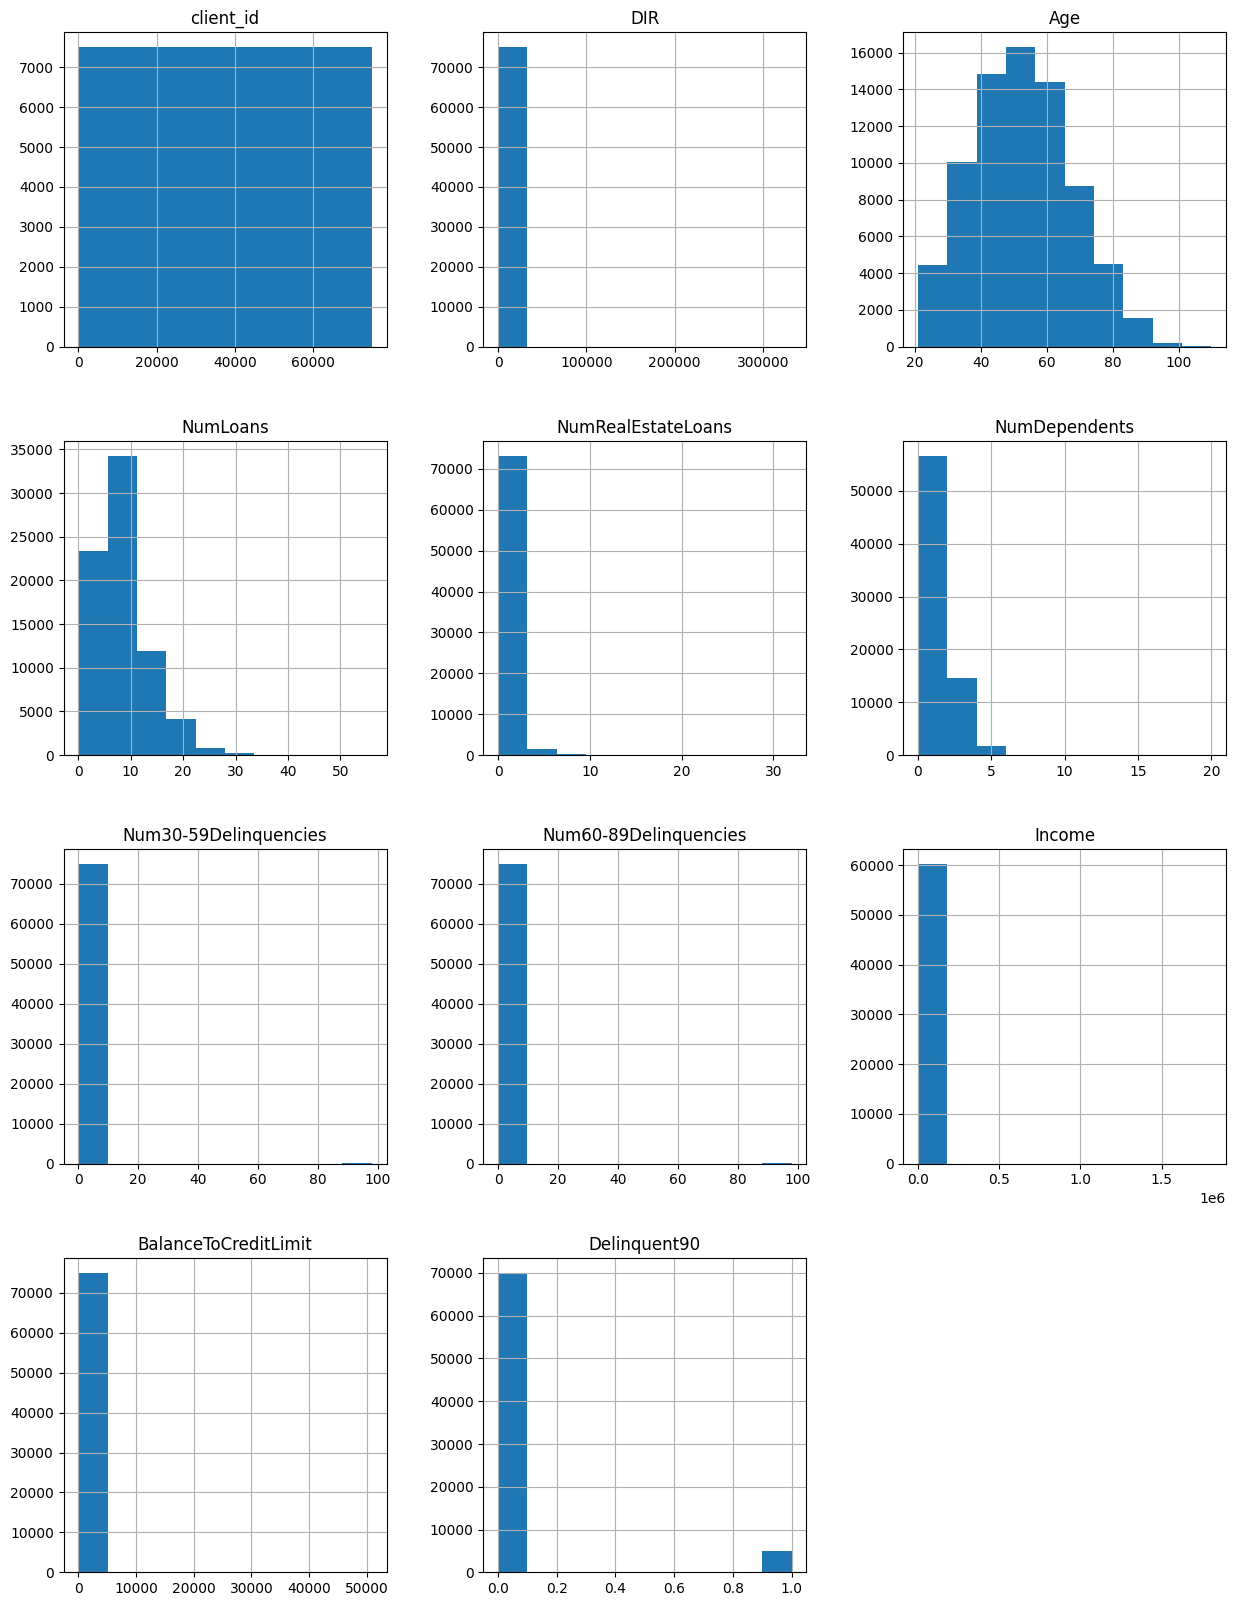

In [4]:
check_data(data)

<div class="alert-success"> 
<b> </b>
    
Сразу можно сказать, что данные выгружены корректно без потерь, пропуски ЕСТЬ и явных дубликатов в данных НЕ ОБНАРУЖЕНО, типы данных НЕ соответствуют содержимому признаков(Age, NumDependents), названия столбцов датафрэйма НЕкорректны. Стоит отметить что уже на данном этапе, по построенным гистограммам видно, что выбросы в данных имеются) </div>

#### 1.2 Предобработатка данных

<div class="alert-success"> 
<b> </b> Для начала переименуем столбцы по правилу хорошего стиля, после поменяем типы данных в столбцах Age, NumDependents, а что касается пропусков - NumDependents - число членов семьи, которых содержит клиент, исключая самого клиента (натуральное число), соответственно просто меняем все пропуски на ноль, так как пропуск значит, что у клиента нет членов семьи которых он содержит)))), Income - месячный доход (вещественный), пропусков много ну я думаю, что можно просто поставить заглушки - "-1"
</div>

In [5]:
data.columns

Index(['client_id', 'DIR', 'Age', 'NumLoans', 'NumRealEstateLoans',
       'NumDependents', 'Num30-59Delinquencies', 'Num60-89Delinquencies',
       'Income', 'BalanceToCreditLimit', 'Delinquent90'],
      dtype='object')

In [6]:
data = data.rename(
    columns={
        'DIR': 'dir', 
        'Age': 'age', 
        'NumLoans': 'num_loans', 
        'NumRealEstateLoans': 'num_real_estate_loans',
        'NumDependents': 'num_dependents',
        'Num30-59Delinquencies': 'num_30_59_delinquencies', 
        'Num60-89Delinquencies': 'num_60_89_delinquencies',
        'Income': 'income', 
        'BalanceToCreditLimit': 'balance_to_credit_limit', 
        'Delinquent90': 'delinquent_90'
        
    }
)

In [7]:
# data.columns

In [8]:
data['age'] = data['age'].astype(int)
data['num_dependents'] = data['num_dependents'].fillna(0).astype(int)
data['income'] = data['income'].fillna(-1)

In [9]:
data

,client_id,dir,age,num_loans,num_real_estate_loans,num_dependents,num_30_59_delinquencies,num_60_89_delinquencies,income,balance_to_credit_limit,delinquent_90
0,0,0.496289,49,13,0,0,2,0,5298.360639,0.387028,0
1,1,0.433567,48,9,2,2,1,0,6008.056256,0.234679,0
2,2,2206.731199,55,21,1,0,1,0,-1.000000,0.348227,0
3,3,886.132793,55,3,0,0,0,0,-1.000000,0.971930,0
4,4,0.000000,52,1,0,0,0,0,2504.613105,1.004350,0
...,...,...,...,...,...,...,...,...,...,...,...
74995,74995,0.169463,67,5,1,0,0,0,20129.654428,0.074689,0
74996,74996,2085.662215,43,1,1,0,0,0,-1.000000,1.005390,0
74997,74997,0.118935,23,4,0,0,2,0,2019.117329,0.384511,0
74998,74998,0.203414,46,14,2,0,0,0,16823.909642,0.524093,0


<div class="alert-success"> 
<b> </b> Посмотрим заново на пропуски)
</div>

In [10]:
data.isna().sum()

client_id                  0
dir                        0
age                        0
num_loans                  0
num_real_estate_loans      0
num_dependents             0
num_30_59_delinquencies    0
num_60_89_delinquencies    0
income                     0
balance_to_credit_limit    0
delinquent_90              0
dtype: int64

<div class="alert-success"> 
<b> </b>
    
1) Преобразованы типы данных
2) Убраны все пропуски
3) Переименованы столбцы 
</div>

#### 1.3 Анализ данных

<div class="alert-success"> 
<b> </b>Для начала, проведем статистический анализ признаков) для этого напишем функцию которая строит гистограмму, "ящик с усами" и круговую диаграмму)
</div>

In [11]:
def hist(column):
    print(data[column].describe())
    plt.hist(data[column])
    plt.title(f'Распределение признака {column}')
    plt.xlabel(column)
    plt.ylabel("Количество квартир")
    plt.show()
def bxplt(column):
    sns.boxplot(data = data, y = column)
    plt.title('Ящик с усами')
    plt.ylabel(column)
def pie(column):
    print(data[column].value_counts())
    fig, ax = plt.subplots()
    ax.pie(data[column].value_counts(), labels=data[column].unique(), autopct='%.2f%%')
    plt.title(f'Распределение признака {column}')

<div class="alert alert-warning">
<b> Признак "dir" - Debt-to-income Ratio </b> 
<br>
</div>

count     75000.000000
mean        353.260293
std        2117.237432
min           0.000000
25%           0.176022
50%           0.366848
75%           0.862650
max      332600.272820
Name: dir, dtype: float64


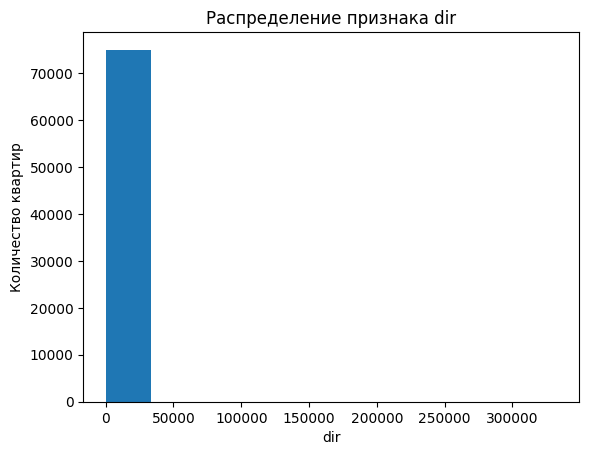

In [12]:
hist('dir')

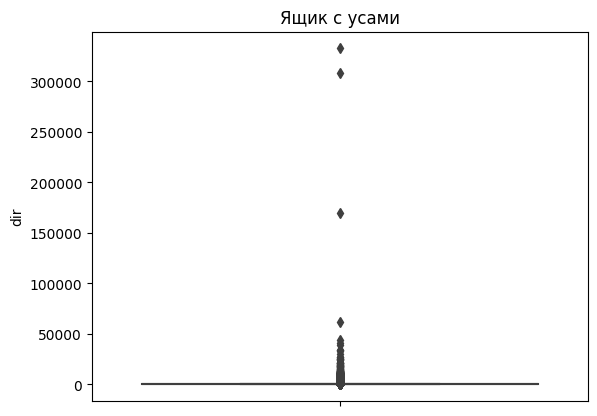

In [13]:
bxplt('dir')

In [14]:
print(f'Процент выбросов в признаке "dir": {(len(data.query("dir > 2")) / len(data) * 100)}%')

Процент выбросов в признаке "dir": 20.75333333333333%


<div class="alert-success"> 
<b> </b>Ну вообще то деревья и бустинговые модели устойчивы к выбросам, поэтому оставим как есть, ну и количество процентов выбросов немалое, так что этот признак не трогаем))
</div>

<div class="alert alert-warning">
<b> Признак "age" - возраст </b> 
<br>
</div>

count    75000.000000
mean        52.334680
std         14.795032
min         21.000000
25%         41.000000
50%         52.000000
75%         63.000000
max        109.000000
Name: age, dtype: float64


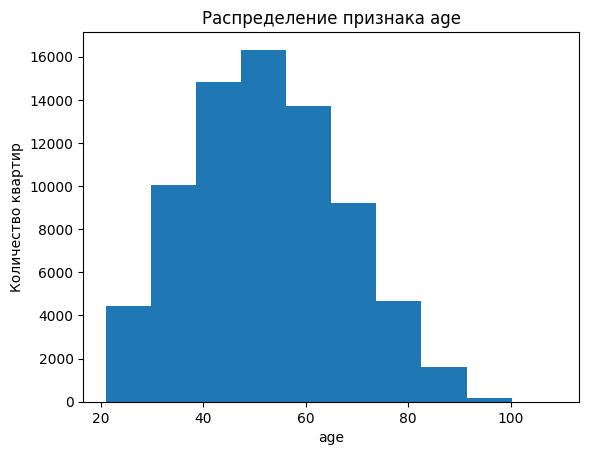

In [15]:
hist('age')

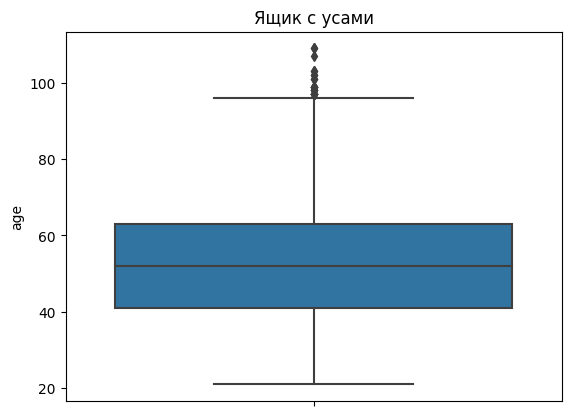

In [16]:
bxplt('age')

In [17]:
print(f'Процент выбросов в признаке "age": {(len(data.query("age > 85")) / len(data) * 100)}%')

Процент выбросов в признаке "age": 1.4093333333333333%


<div class="alert-success"> 
<b> </b>Оставляем как есть)
</div>

<div class="alert alert-warning">
<b> Признак "num_loans" - число заемов и кредитных линий </b> 
<br>
</div>

count    75000.00000
mean         8.44976
std          5.15644
min          0.00000
25%          5.00000
50%          8.00000
75%         11.00000
max         56.00000
Name: num_loans, dtype: float64


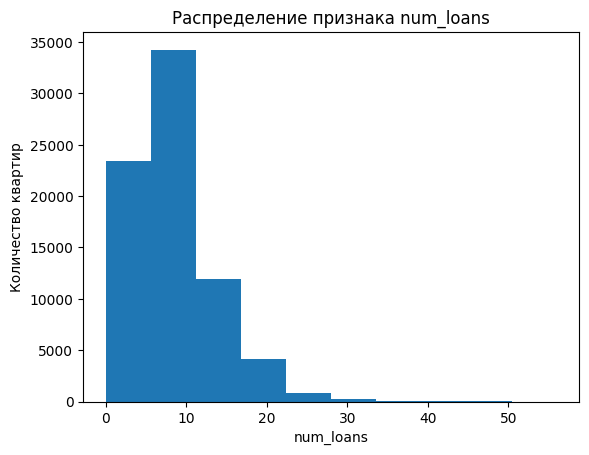

In [18]:
hist('num_loans')

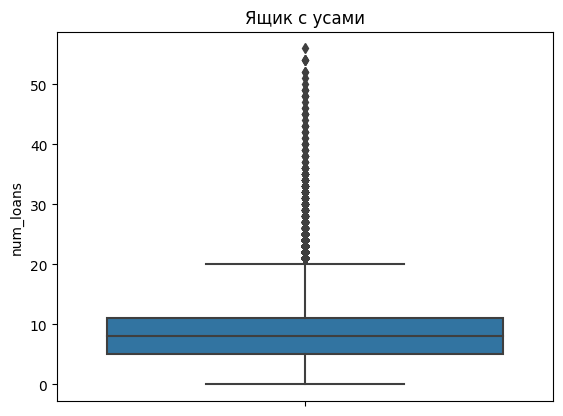

In [19]:
bxplt('num_loans')

In [20]:
print(f'Процент выбросов в признаке "num_loans": {(len(data.query("num_loans > 20")) / len(data) * 100)}%')

Процент выбросов в признаке "num_loans": 2.666666666666667%


<div class="alert-success"> 
<b> </b>Тоже оставим как есть
</div>

<div class="alert alert-warning">
<b> Признак "num_real_estate_loans" - число ипотек и заемов, связанных с недвижимостью  </b> 
<br>
</div>

count    75000.000000
mean         1.016693
std          1.124019
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         32.000000
Name: num_real_estate_loans, dtype: float64


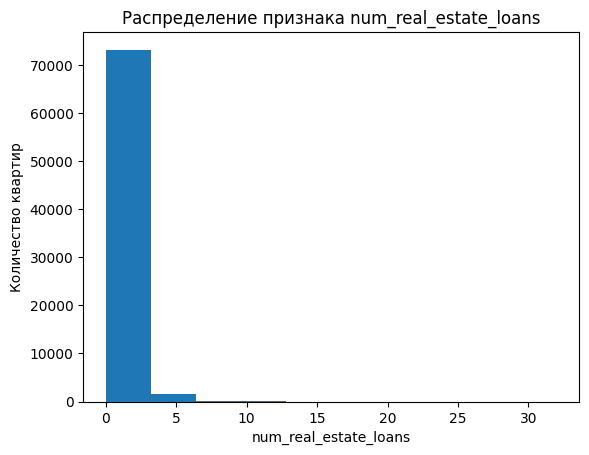

In [21]:
hist('num_real_estate_loans')

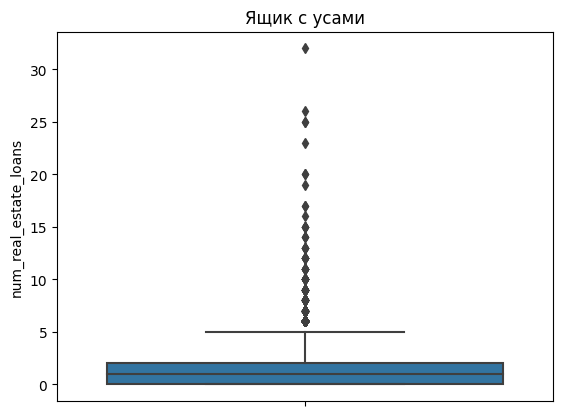

In [22]:
bxplt('num_real_estate_loans')

In [23]:
print(f'Процент выбросов в признаке "num_real_estate_loans": {(len(data.query("num_real_estate_loans > 5")) / len(data) * 100)}%')

Процент выбросов в признаке "num_real_estate_loans": 0.5680000000000001%


<div class="alert-success"> 
<b> </b>Тоже оставим как есть, потому что выбросы как раз таки и могут быть связаны с задержкой по кредиту)
</div>

<div class="alert alert-warning">
<b> Признак "num_dependents" - число членов семьи, которых содержит клиент, исключая самого клиента </b> 
<br>
</div>

count    75000.000000
mean         0.736653
std          1.100357
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         20.000000
Name: num_dependents, dtype: float64


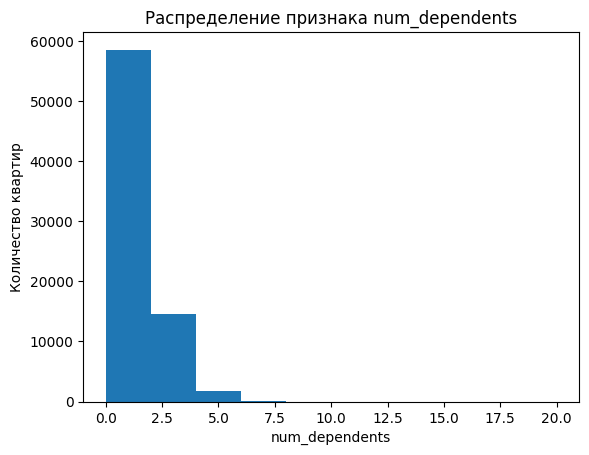

In [24]:
hist('num_dependents')

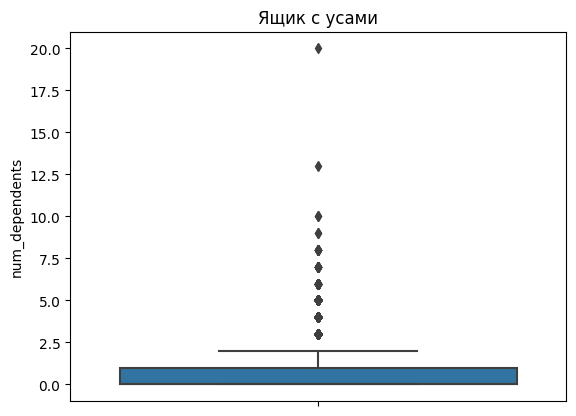

In [25]:
bxplt('num_dependents')

In [26]:
print(f'Процент выбросов в признаке "num_dependents": {(len(data.query("num_dependents > 2.4")) / len(data) * 100)}%')

Процент выбросов в признаке "num_dependents": 8.690666666666665%


<div class="alert-success"> 
<b> </b>Слишком много выбросов - оставляем
</div>

<div class="alert alert-warning">
<b> Признак "num_30_59_delinquencies" - число просрочек выплат по кредиту от 30 до 59 дней  </b> 
<br>
</div>

count    75000.000000
mean         0.428320
std          4.276439
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         98.000000
Name: num_30_59_delinquencies, dtype: float64


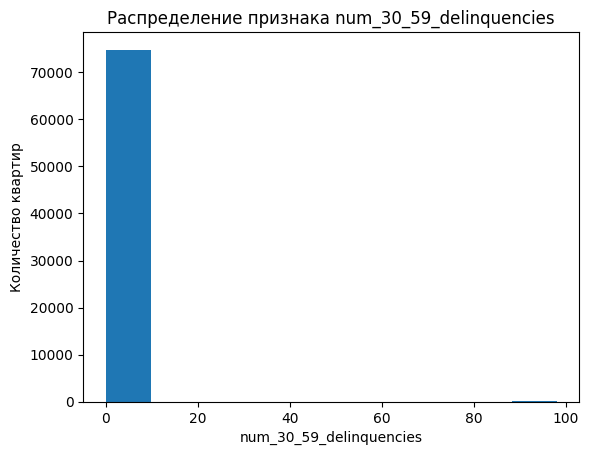

In [27]:
hist('num_30_59_delinquencies')

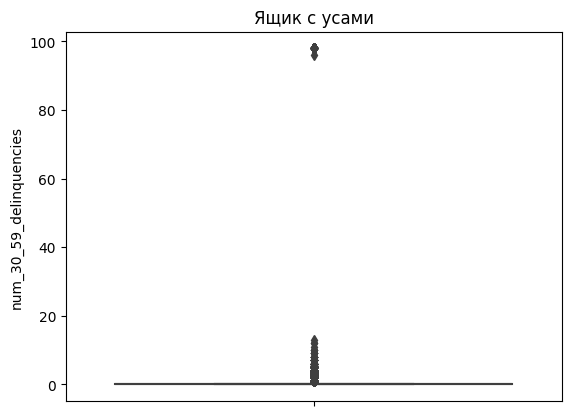

In [28]:
bxplt('num_30_59_delinquencies')

<div class="alert-success"> 
<b> </b>Тут итак понятно, что выбросов очень много, я вообще боюсь что то удалять, потому что возможно что выбросы это как раз таки и значит, что клиент неплатежеспособен и длительное время не выплачивает кредит и у него естиь большое количество просрочек и поэтому возможны и просрочки более 90 дней, но в этот раз удалю аномалии которые больше 20
</div>

In [29]:
data = data.query("num_30_59_delinquencies < 20")

<div class="alert alert-warning">
<b> Признак "num_60_89_delinquencies" - число просрочек выплат по кредиту от 60 до 89 дней  </b> 
<br>
</div>

count    74860.000000
mean         0.065215
std          0.328895
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         11.000000
Name: num_60_89_delinquencies, dtype: float64


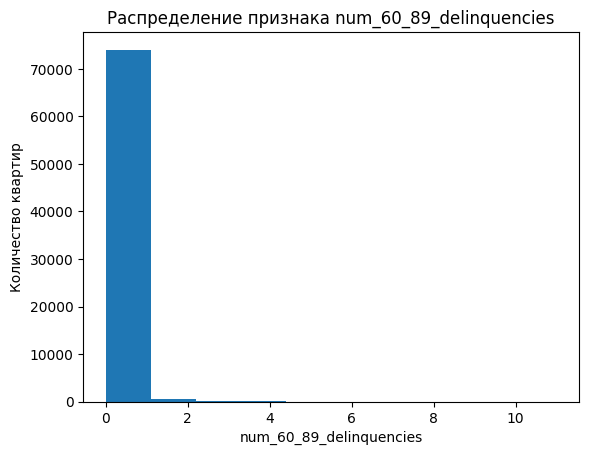

In [30]:
hist('num_60_89_delinquencies')

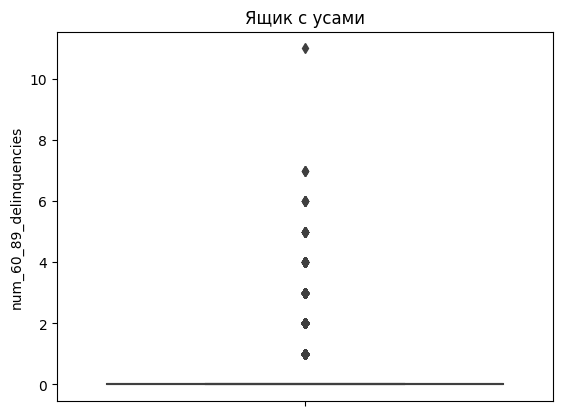

In [31]:
bxplt('num_60_89_delinquencies')

<div class="alert-success"> 
<b> </b>Слишком много выбросов - оставляем
</div>

<div class="alert alert-warning">
<b> Признак "income" - месячный доход </b> 
<br>
</div>

count    7.486000e+04
mean     5.413575e+03
std      1.303349e+04
min     -1.000000e+00
25%      1.600548e+03
50%      4.406188e+03
75%      7.417693e+03
max      1.805573e+06
Name: income, dtype: float64


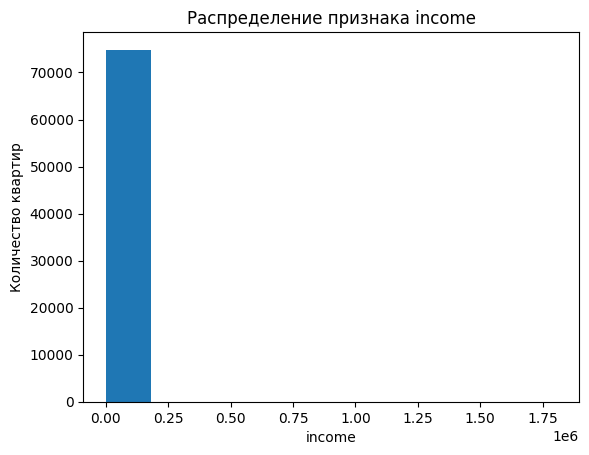

In [32]:
hist('income')

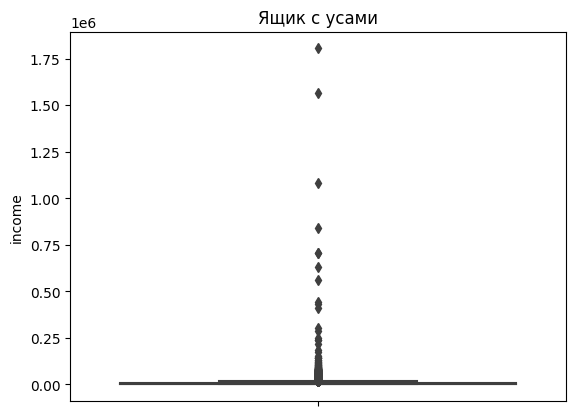

In [33]:
bxplt('income')

In [34]:
print(f'Процент выбросов в признаке "income": {(len(data.query("income > 20000")) / len(data) * 100)}%')

Процент выбросов в признаке "income": 1.5695965802831953%


<div class="alert-success"> 
<b> </b>В этом случаем можно убрать выбросы)
</div>

In [35]:
data = data.query("income <= 20000")

<div class="alert alert-warning">
<b> Признак "balance_to_credit_limit" - отношение баланса на кредитной карте к лимту по кредиту  </b> 
<br>
</div>

count    73685.000000
mean         5.666099
std        194.427397
min          0.000000
25%          0.029510
50%          0.152838
75%          0.559487
max      20551.547563
Name: balance_to_credit_limit, dtype: float64


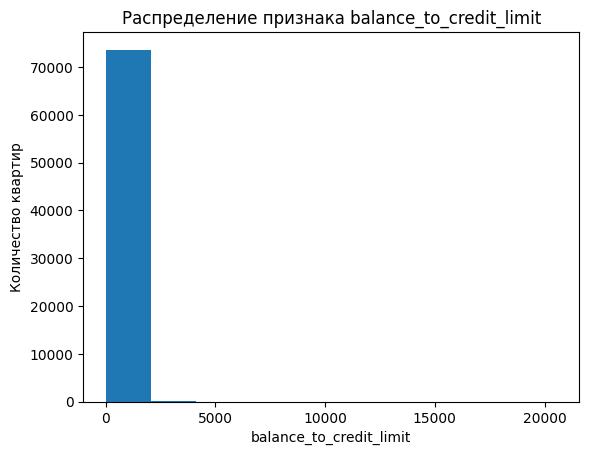

In [36]:
hist('balance_to_credit_limit')

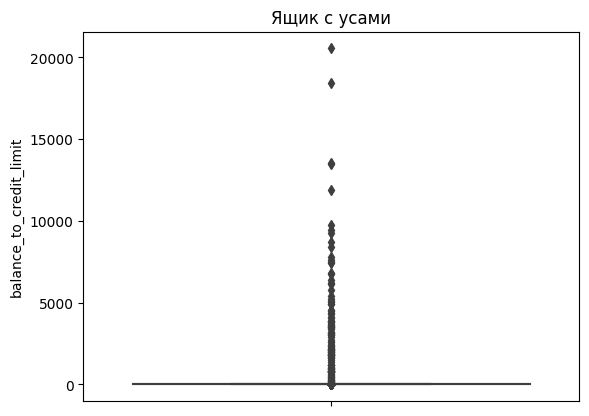

In [37]:
bxplt('balance_to_credit_limit')

In [38]:
print(f'Процент выбросов в признаке "balance_to_credit_limit": {(len(data.query("balance_to_credit_limit > 1.5")) / len(data) * 100)}%')

Процент выбросов в признаке "balance_to_credit_limit": 0.4220669064260026%


In [39]:
data = data.query("balance_to_credit_limit <= 1.5")

<div class="alert alert-warning">
<b> Признак "delinquent_90" - Таргет, были ли просрочки выплат по кредиту более 90 дней (бинарный) </b> 
<br>
</div>

0    68573
1     4801
Name: delinquent_90, dtype: int64


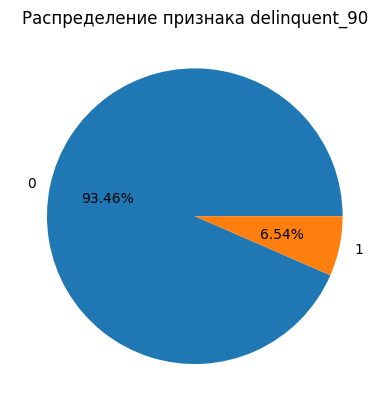

In [40]:
pie('delinquent_90')

<div class="alert-success"> 
<b> </b>Дисбаланс классов) Нужно избавляться)
</div>

In [41]:
# создаём список с наименованиями непрерывных признаков
interval_cols = ['dir', 'age', 'num_loans', 'num_real_estate_loans', 'num_dependents', 'num_30_59_delinquencies', 'num_60_89_delinquencies', 'income', 'balance_to_credit_limit']

# считаем корреляции на выборке
phik_overview = phik_matrix(data.drop(['client_id'], axis=1), interval_cols=interval_cols)
print(phik_overview.shape)

(10, 10)


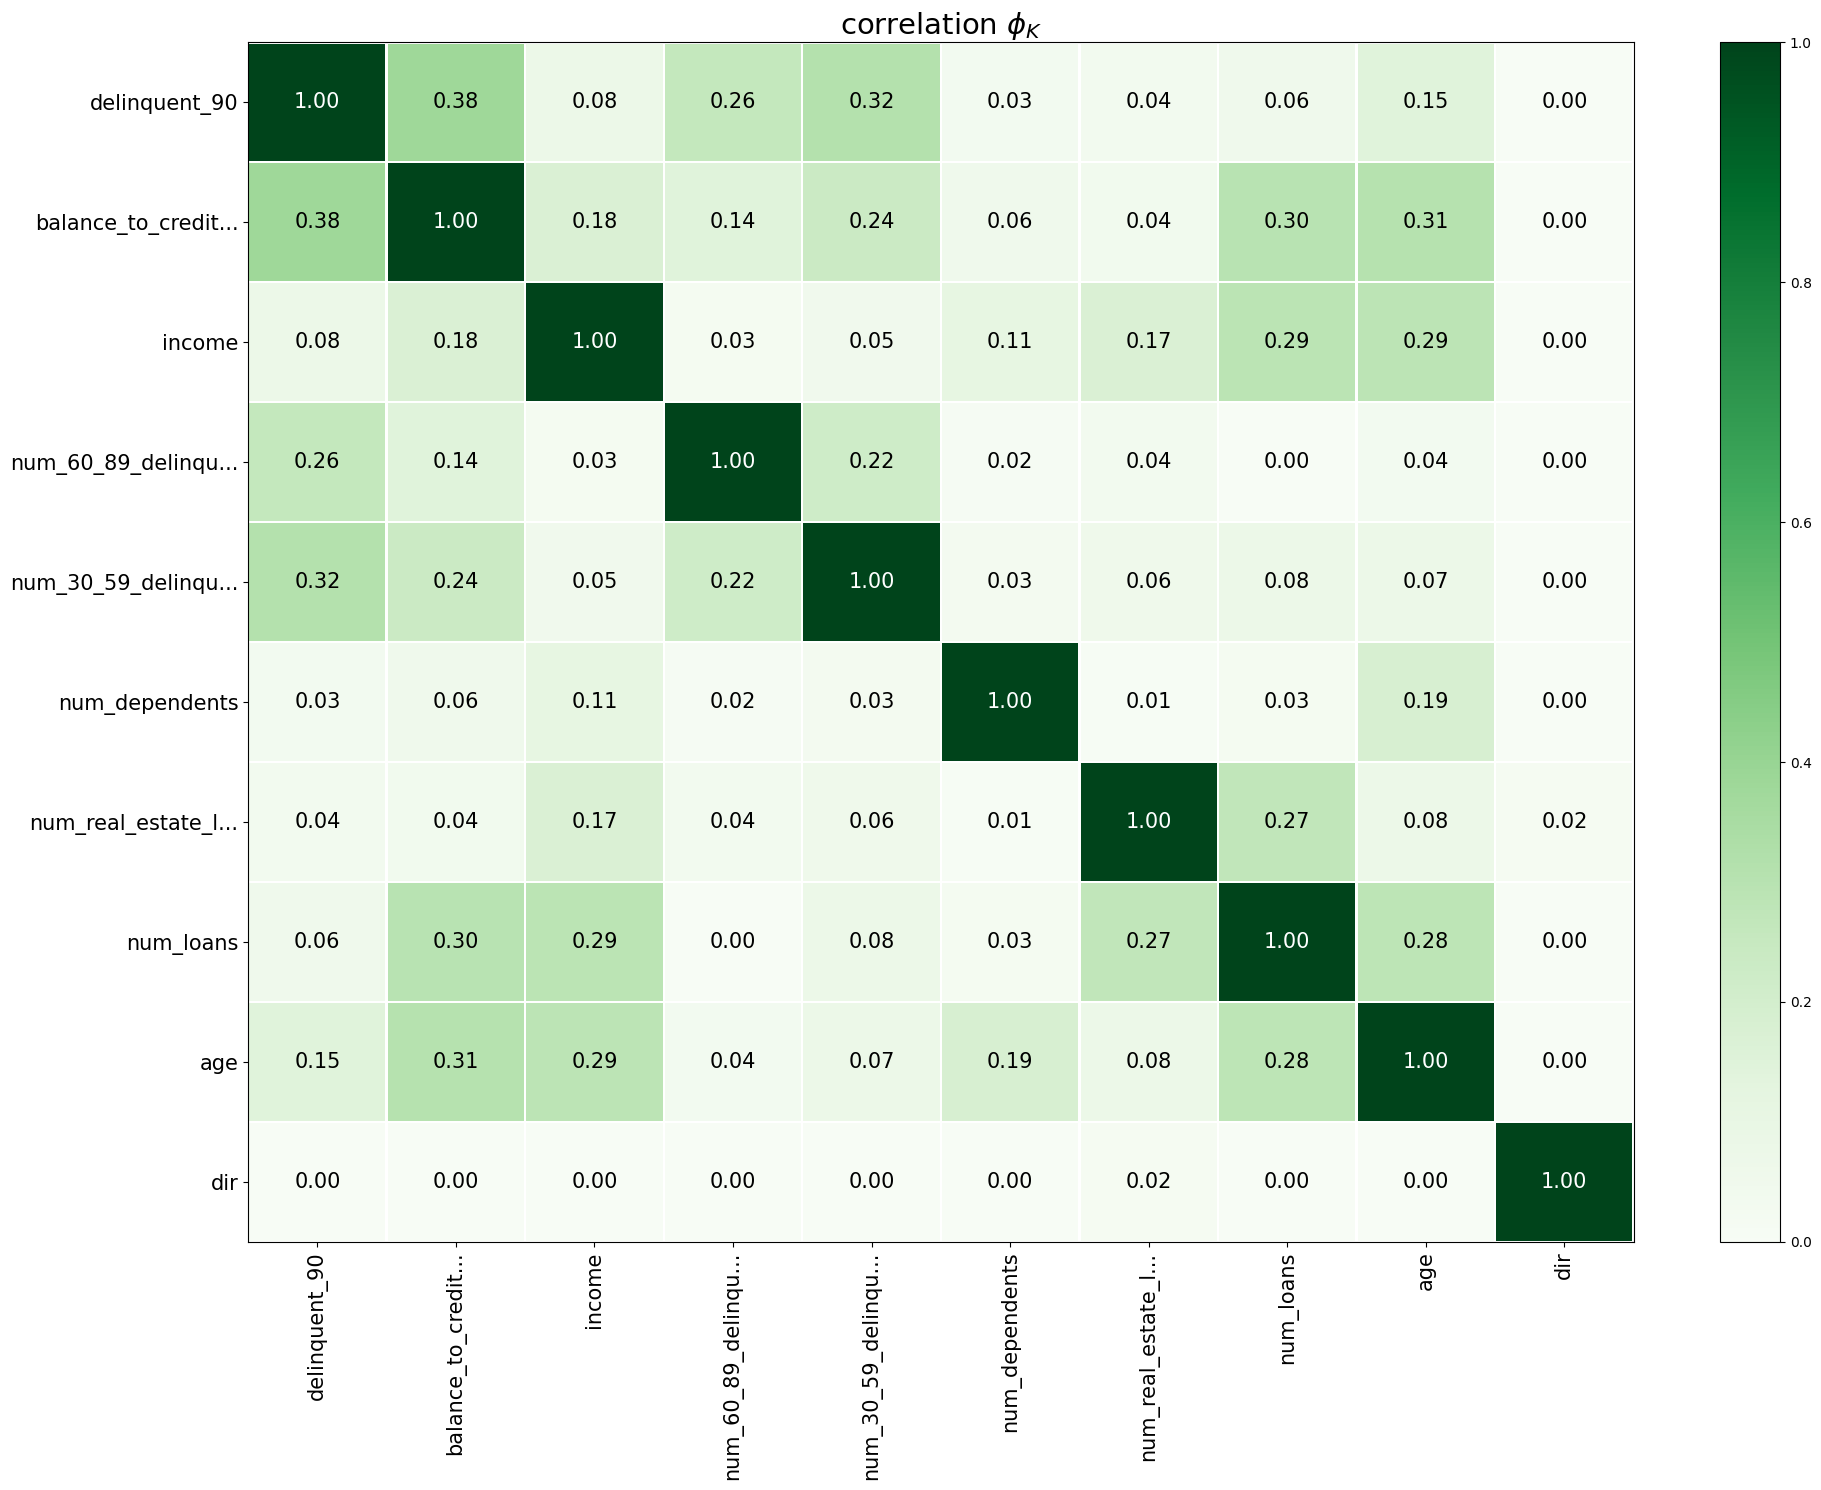

In [42]:
# Функции передаём значения матрицы корреляции phik_overview.values.
# Указываем наименования столбцов x_labels=phik_overview.columns.
# Указываем наименования строк y_labels=phi k_overview.index.
# Указываем цвет градиентной отрисовки vmin=0, vmax=1, color_map='Greens'.
# Добавляем заголовок title=r'correlation $\phi_K$'.
# Увеличиваем размер шрифта fontsize_factor=1.5.
# Увеличиваем размер графика figsize=(20, 15).

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

<div class="alert-success"> 
<b> </b>все нормально, утечки целевого признака нет и мкльтиколлениарности тоже - нет, также признак dir не несет в себе никакой полезной инфы для нашего целевого признака - можно удалять)
</div>

In [43]:
data = data.drop(['dir'], axis=1)

#### 1.4 Кодирование данных

<div class="alert-success"> 
<b> </b>Все признаки количественные, не считая таргетного, поэтому просто стандартизируем данные. А вообще, для деревьев и ансамблей  — не нужно использовать ни стандартизацию, ни нормализацию вообще, но я лучше перестрахуюсь, хуже не будет). Кодирование сделаем потом еще и в пайплайне. А устраним дисбаланс с помощью undersamplingа)
</div>

In [44]:
# data.columns

In [45]:
num_columns = ['age', 'num_loans', 'num_real_estate_loans', 'num_dependents', 'num_30_59_delinquencies', 'num_60_89_delinquencies', 'income', 'balance_to_credit_limit']

In [46]:
X = data.drop(['client_id', 'delinquent_90'], axis=1).reset_index(drop=True)
y = data['delinquent_90'].reset_index(drop=True)

In [47]:
# X

In [48]:
# y

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

In [50]:
sampler = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_sampled, y_train_sampled = sampler.fit_resample(X_train, y_train)
# smote = SMOTE(random_state=RANDOM_STATE)
# X_train_sampled, y_train_sampled = smote.fit_resample(X_train, y_train)

<div class="alert-success"> 
<b> </b>Вот здесь я попробовала сделать сэмплирование SMOTE ---> результат грид серч находит медленее, так как данных очень много, модель обучается медленее, f1_score наоборот упала(, плэтому оставила Under сэмплирование)
</div>

In [51]:
X_train_sampled.shape, y_train_sampled.shape

((7202, 8), (7202,))

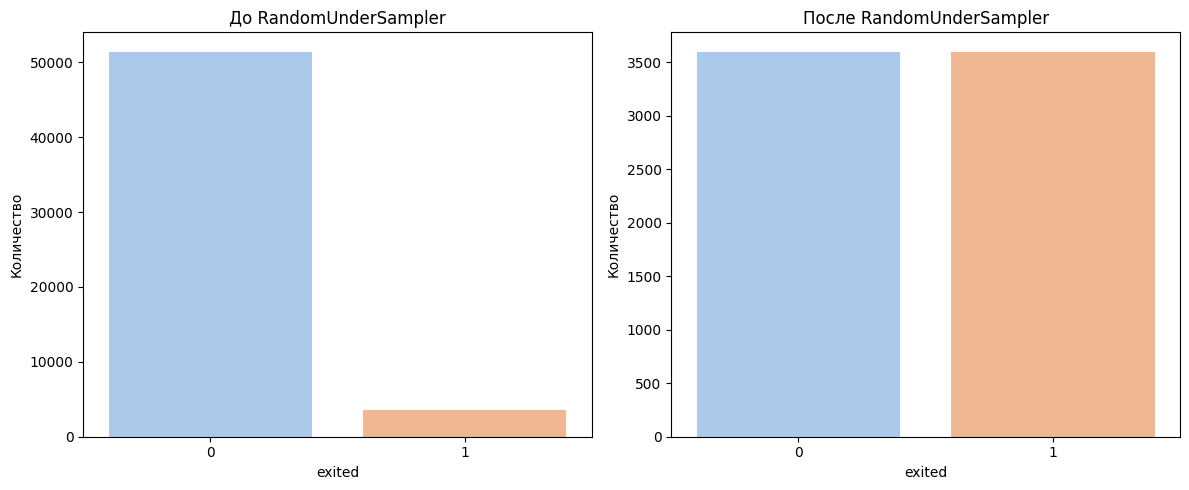

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0], palette='pastel')
axes[0].set_title('До RandomUnderSampler')
axes[0].set_xlabel('exited')
axes[0].set_ylabel('Количество')

sns.countplot(x=y_train_sampled, ax=axes[1], palette='pastel')
axes[1].set_title('После RandomUnderSampler')
axes[1].set_xlabel('exited')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

### Шаг 2. Решение задачи бинарной классификации: Дерево решений

<div class="alert-success"> 
<b> </b>Итак, на данном этапе нам надо обучить дерево решений и визуализировать решающее дерево. При этом нужно рассмотреть, как изменение глубины дерева влияет на качество модели, т.е обучить решающее дерево с различной глубиной (от 1 до 11) и оценить его точность и определить, когда начинается переобучение и какая глубина дерева является оптимальной. Подобрать оптимальные параметры дерева с помощью GridSearhCV. 


Ниже, соберем наш пайплайн)
</div>

In [53]:
data_preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough',
    force_int_remainder_cols=False  
)

In [54]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [55]:
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(1, 12),
        'preprocessor__num': [StandardScaler()]
    }
    
]
grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='f1',
    # random_state=RANDOM_STATE,
    n_jobs=-1
)
grid_search.fit(X_train_sampled, y_train_sampled)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'num_loans',
                                                                          'num_real_estate_loans',
                                                                          'num_dependents',
                                                                          'num_30_59_delinquencies',
                                                                          'num_60_89_delinquencies',
                                                                          'income',
                                                                          'balance_to_credit_limit'])])),
                                       ('models',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'models': [DecisionTreeClassifier(random_state=42)],
                          'models__max_depth': range(1, 12),
                          'preprocessor__num': [StandardScaler()]}],
             scoring='f1')

In [56]:
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)
y_test_pred = grid_search.predict(X_test)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'num_loans',
                                                   'num_real_estate_loans',
                                                   'num_dependents',
                                                   'num_30_59_delinquencies',
                                                   'num_60_89_delinquencies',
                                                   'income',
                                                   'balance_to_credit_limit'])])),
                ('models',
                 DecisionTreeClassifier(max_depth=2, random_state=42))])
Метрика лучшей модели на тренировочной выборке: 0.7616690789588342
Метрика ROC-AUC на тестовой выборке: 0.73000486078

In [57]:
best_model = grid_search.best_estimator_.named_steps['models']
probabilities = grid_search.predict_proba(X_test)
probabilities_one = probabilities[:, 1]
print('Вероятностный ROC-AUC:', roc_auc_score(y_test, probabilities_one))

Вероятностный ROC-AUC: 0.7781174657800592


In [58]:
f1 = f1_score(y_test, y_test_pred)
print(f'F1-мера на тестовой выборке: {f1:.4f}')

F1-мера на тестовой выборке: 0.2279


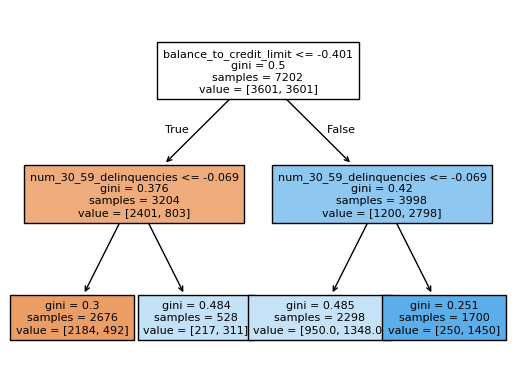

In [59]:
plot_tree(best_model, feature_names=X.columns, filled=True, fontsize=8);

<div class="alert-success"> 
<b> </b>Итак, наш поиск по сетке выдал, что лучшей моделью является решающее дерево с глубиной 2, теперь переберем все гиперпараметры модели вручную) Напишем функцию)-->
</div>

In [60]:
def DTClass(num):
    model = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=num)
    model.fit(X_train_sampled, y_train_sampled)

    y_train_pred = model.predict(X_train_sampled)
    y_test_pred = model.predict(X_test)
    
    y_train_proba = model.predict_proba(X_train_sampled)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    print(f'Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной {num}: {roc_auc_score(y_train_sampled, y_train_pred)}')
    print(f'Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной {num}: {roc_auc_score(y_test, y_test_pred)}')
    
    print(f'Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной {num}: {roc_auc_score(y_train_sampled, y_train_proba)}')
    print(f'Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной {num}: {roc_auc_score(y_test, y_test_proba)}')
    
    print(f'F1-мера на тренировочной выборке Дерева решений с глубиной {num}: {f1_score(y_train_sampled, y_train_pred)}')
    print(f'F1-мера на тестовой выборке Дерева решений с глубиной {num}: {f1_score(y_test, y_test_pred)}')

    # plot_tree(model, feature_names=X.columns, filled=True, fontsize=8);

In [61]:
DTClass(1)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 1: 0.7218828103304638
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 1: 0.7194361487011978
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 1: 0.7218828103304638
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 1: 0.7194361487011978
F1-мера на тренировочной выборке Дерева решений с глубиной 1: 0.736412685879721
F1-мера на тестовой выборке Дерева решений с глубиной 1: 0.2360722462477741


In [62]:
DTClass(2)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 2: 0.7349347403499028
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 2: 0.7300048607870588
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 2: 0.7843029116306595
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 2: 0.7781174657800592
F1-мера на тренировочной выборке Дерева решений с глубиной 2: 0.7651039744063
F1-мера на тестовой выборке Дерева решений с глубиной 2: 0.22789304338178187


In [63]:
DTClass(3)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 3: 0.7443765620660927
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 3: 0.7375894384818789
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 3: 0.8101903409995728
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 3: 0.8035384342432726
F1-мера на тренировочной выборке Дерева решений с глубиной 3: 0.7233658903080391
F1-мера на тестовой выборке Дерева решений с глубиной 3: 0.3079922027290448


In [64]:
DTClass(4)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 4: 0.7561788392113302
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 4: 0.7470854720796392
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 4: 0.82546561127571
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 4: 0.8119950857442839
F1-мера на тренировочной выборке Дерева решений с глубиной 4: 0.7407735459108356
F1-мера на тестовой выборке Дерева решений с глубиной 4: 0.3116093482804484


In [65]:
DTClass(5)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 5: 0.7667314634823661
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 5: 0.7508871908539432
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 5: 0.83884077990308
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 5: 0.8185510965935605
F1-мера на тренировочной выборке Дерева решений с глубиной 5: 0.7671194898807874
F1-мера на тестовой выборке Дерева решений с глубиной 5: 0.28658732711482793


In [66]:
DTClass(6)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 6: 0.7742293807275757
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 6: 0.7485281536786437
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 6: 0.850929086392661
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 6: 0.818353456991756
F1-мера на тренировочной выборке Дерева решений с глубиной 6: 0.7690996875887532
F1-мера на тестовой выборке Дерева решений с глубиной 6: 0.2952789699570815


In [67]:
DTClass(7)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 7: 0.7811718966953624
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 7: 0.7494911728107014
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 7: 0.8622976153450541
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 7: 0.8109134148001245
F1-мера на тренировочной выборке Дерева решений с глубиной 7: 0.7795804195804196
F1-мера на тестовой выборке Дерева решений с глубиной 7: 0.28823818092589565


In [68]:
DTClass(8)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 8: 0.7947792279922243
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 8: 0.7361961424793902
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 8: 0.8774947268882468
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 8: 0.7958794135946493
F1-мера на тренировочной выборке Дерева решений с глубиной 8: 0.7964187327823692
F1-мера на тестовой выборке Дерева решений с глубиной 8: 0.2692012877510348


In [69]:
DTClass(9)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 9: 0.8078311580116634
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 9: 0.7308401384352154
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 9: 0.8932128837981305
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 9: 0.7827945393918183
F1-мера на тренировочной выборке Дерева решений с глубиной 9: 0.797067448680352
F1-мера на тестовой выборке Дерева решений с глубиной 9: 0.2905982905982906


In [70]:
DTClass(10)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 10: 0.8236600944182171
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 10: 0.718275198320112
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 10: 0.9099596744123887
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 10: 0.7661019404261937
F1-мера на тренировочной выборке Дерева решений с глубиной 10: 0.8218294051627385
F1-мера на тестовой выборке Дерева решений с глубиной 10: 0.2589188347094563


In [71]:
DTClass(11)

Метрика ROC-AUC на тренировочной выборке Дерева решений с глубиной 11: 0.8426825881699528
Метрика ROC-AUC на тестовой выборке Дерева решений с глубиной 11: 0.7177541219474257
Метрика ROC-AUC(вероятностный) на тренировочной выборке Дерева решений с глубиной 11: 0.9272094263056461
Метрика ROC-AUC(вероятностный) на тестовой выборке Дерева решений с глубиной 11: 0.7483574428371442
F1-мера на тренировочной выборке Дерева решений с глубиной 11: 0.8398586572438163
F1-мера на тестовой выборке Дерева решений с глубиной 11: 0.26129853596435393


<div class="alert-success"> 
<b> </b> Переобучение начинается примерно с глубины 8, а становится явно выраженным с глубины 9 и выше, так как --->
    

- До примерно 6 глубины дерево ещё ведёт себя стабильно — метрики на трейне и тесте близкие, ROC-AUC на тесте держится нормально.
- С 7 глубины начинается расхождение: на тренировке всё лучше и лучше, F1 растёт, а на тесте наоборот падает.
- ROC-AUC тоже начинает уходить вниз на тесте, разрыв между трейном и тестом становится заметным.
- После 8 глубины переобучение уже очевидное — дерево запоминает обучающие данные, F1 на трейне высокий, на тесте всё хуже.


Короче, переобучение начинается где-то с 8 глубины, а после 9–10 становится выраженным.
</div>

<div class="alert-success"> 
<b> </b> Вывод к шагу 2 - ПЕРЕОБУЧЕНИЕ начинается с 8 глубины дерева, ОПТИМАЛЬНАЯ ГЛУБИНА - 6 (ПО МОЕМУ МНЕНИЮ, так как лучшая f1 score), по мнению гридсерч - оптимальная глубина - 2.
    
- Я бы не стала использовать дерево решений для данной задачи, метрика f1 слишком низкая на тестовой выборке)
</div>

### Шаг 3. Решение задачи бинарной классификации: Ансамблевый методы

#### 3.1 BaggingClassifier

<div class="alert-success"> 
<b> </b> На данном этапе ----> Необходимо выбрать любую классическую модель (не ансамблевую) и обучить ансамбль с помощью бэггинга (BaggingClassifier). Подобрать оптимальные параметры как  бэггинга так и модели с помощью GridSearhCV.
</div>

<div class="alert-success"> 
<b> </b> Так как одно дерево решений само по себе НЕ ЯВЛЯЕТСЯ ансамблевой моделью, то возьмем его за основу)
</div>

In [72]:
param_grid = [
    {
        'models': [BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            random_state=RANDOM_STATE
        )],
        'models__estimator__max_depth': range(2, 8), # перебираю гиперпараметр дерева
        'models__n_estimators': [50, 100], # гиперпараметр бэггинга
        'models__max_samples': [0.1, 0.5, 1.0], # гиперпараметр бэггинга
        'models__max_features': [0.5, 1.0], # гиперпараметр бэггинга
        'preprocessor__num': [StandardScaler(), 'passthrough'] # ну это тут просто с кодировщиком и без)
    }
    
]
grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='roc_auc',
    # random_state=RANDOM_STATE,
    n_jobs=-1
)
grid_search.fit(X_train_sampled, y_train_sampled)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'num_loans',
                                                                          'num_real_estate_loans',
                                                                          'num_dependents',
                                                                          'num_30_59_delinquencies',
                                                                          'num_60_89_delinquencies',
                                                                          'income',
                                                                          'balance_to_credit_limit'])])),
                                       ('models',
                                        DecisionTreeClass...m_state=42))]),
             n_jobs=-1,
             param_grid=[{'models': [BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                                       random_state=42)],
                          'models__estimator__max_depth': range(2, 8),
                          'models__max_features': [0.5, 1.0],
                          'models__max_samples': [0.1, 0.5, 1.0],
                          'models__n_estimators': [50, 100],
                          'preprocessor__num': [StandardScaler(),
                                                'passthrough']}],
             scoring='roc_auc')

In [73]:
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)
y_test_pred = grid_search.predict(X_test)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'num_loans',
                                                   'num_real_estate_loans',
                                                   'num_dependents',
                                                   'num_30_59_delinquencies',
                                                   'num_60_89_delinquencies',
                                                   'income',
                                                   'balance_to_credit_limit'])])),
                ('models',
                 BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                                    random_state=42),
                       

In [74]:
best_model = grid_search.best_estimator_.named_steps['models']
probabilities = grid_search.predict_proba(X_test)
probabilities_one = probabilities[:, 1]
print('Вероятностный ROC-AUC на тестовой выборке:', roc_auc_score(y_test, probabilities_one))

Вероятностный ROC-AUC на тестовой выборке: 0.8397992251905428


In [75]:
# f1 = f1_score(y_test, y_test_pred)
# print(f'F1-мера на тестовой выборке: {f1:.4f}')

#### 3.2 StackingClassifier

<div class="alert-success"> 
<b> </b> Ниже будет выбрано несколько классических моделей (не ансамблевых) и обучен ансамбль с помощью стекинга (StackingClassifier). Оптимальные параметры как  стекинга так и модели будут подбираться с помощью GridSearhCV --->

ПОИСК ЗАНЯЛ МЕНЕЕ 10 МИНУТ)
</div>

In [76]:
param_grid = [
    {
        'models': [StackingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
                ('svm', SVC(random_state=RANDOM_STATE))
            ],
            final_estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_jobs=-1
        )],

        'models__stack_method': ['auto', 'predict'],
        # 'models__passthrough': [True, False],
        # 'models__cv': [3, 5],

        'models__lr__C': [0.01, 0.1],
        'models__lr__penalty': ['l2'],
        
        'models__svm__C': [1],
        'models__svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        # 'models__svm__gamma': ['scale', 'auto'],

        'models__final_estimator__max_depth': range(5, 7),
        # 'models__final_estimator__min_samples_split': [2, 5, 10],

        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    }
]

grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    # random_state=RANDOM_STATE,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_sampled, y_train_sampled)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'num_loans',
                                                                          'num_real_estate_loans',
                                                                          'num_dependents',
                                                                          'num_30_59_delinquencies',
                                                                          'num_60_89_delinquencies',
                                                                          'income',
                                                                          'balance_to_credit_limit'])])),
                                       ('models',
                                        DecisionTreeClass...
                                                        final_estimator=DecisionTreeClassifier(random_state=42),
                                                        n_jobs=-1)],
                          'models__final_estimator__max_depth': range(5, 7),
                          'models__lr__C': [0.01, 0.1],
                          'models__lr__penalty': ['l2'],
                          'models__stack_method': ['auto', 'predict'],
                          'models__svm__C': [1],
                          'models__svm__kernel': ['linear', 'rbf', 'poly',
                                                  'sigmoid'],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler()]}],
             scoring='roc_auc')

In [77]:
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)
y_test_pred = grid_search.predict(X_test)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'num_loans',
                                                   'num_real_estate_loans',
                                                   'num_dependents',
                                                   'num_30_59_delinquencies',
                                                   'num_60_89_delinquencies',
                                                   'income',
                                                   'balance_to_credit_limit'])])),
                ('models',
                 StackingClassifier(estimators=[('lr',
                                                 LogisticRegression(C=0.1,
                                                            

In [78]:
print('Метрика accuracy на тестовой выборке:', accuracy_score(y_test, y_test_pred))

Метрика accuracy на тестовой выборке: 0.7884321849105975


In [79]:
# f1 = f1_score(y_test, y_test_pred)
# print(f'F1-мера на тестовой выборке: {f1:.4f}')

#### 3.3 RandomForestClassifier

<div class="alert-success"> 
<b> </b> Обучение cлучайного леса (RandomForestClassifier), с перебором гиперпараметров случайного леса с помощью GridSearhCV --->
</div> 

In [80]:
param_grid = [
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': range(19, 25),
        'models__max_depth': range(6, 15),
        'preprocessor__num': [StandardScaler(), 'passthrough']
    }
]

grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_sampled, y_train_sampled)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'num_loans',
                                                                          'num_real_estate_loans',
                                                                          'num_dependents',
                                                                          'num_30_59_delinquencies',
                                                                          'num_60_89_delinquencies',
                                                                          'income',
                                                                          'balance_to_credit_limit'])])),
                                       ('models',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'models': [RandomForestClassifier(random_state=42)],
                          'models__max_depth': range(6, 15),
                          'models__n_estimators': range(19, 25),
                          'preprocessor__num': [StandardScaler(),
                                                'passthrough']}],
             scoring='roc_auc')

In [81]:
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)
y_test_pred = grid_search.predict(X_test)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'num_loans',
                                                   'num_real_estate_loans',
                                                   'num_dependents',
                                                   'num_30_59_delinquencies',
                                                   'num_60_89_delinquencies',
                                                   'income',
                                                   'balance_to_credit_limit'])])),
                ('models',
                 RandomForestClassifier(max_depth=7, n_estimators=24,
                                        random_state=42))])
Метрика лучшей модели на тренировочной выборке: 0.8362511568

In [82]:
best_model = grid_search.best_estimator_.named_steps['models']
probabilities = grid_search.predict_proba(X_test)
probabilities_one = probabilities[:, 1]
print('Вероятностный ROC-AUC на тестовой выборке:', roc_auc_score(y_test, probabilities_one))

Вероятностный ROC-AUC на тестовой выборке: 0.8363212348343443


In [83]:
print('Метрика accuracy на тестовой выборке:', accuracy_score(y_test, y_test_pred))

Метрика accuracy на тестовой выборке: 0.7590492804186655


#### 3.4 XGBoost

<div class="alert-success"> 
<b> </b> Инициализация параметров и обучение классификатора XGBoost (обратите внимание, что XGBoost работает только с числовыми признаками). Вычисление F test (не F score!) для оценки важности признаков в XGBoost --->
</div>

In [84]:
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('models', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

In [85]:
param_grid = [
    {
        'models': [XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')],
        'models__n_estimators': [50, 100, 150],
        'models__max_depth': [3, 5, 7],
        'models__scale_pos_weight': [1, 5, 10]
        # 'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_sampled, y_train_sampled)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('models',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance...
                                                   max_cat_threshold=None,
                                                   max_cat_to_onehot=None,
                                                   max_delta_step=None,
                                                   max_depth=None,
                                                   max_leaves=None,
                                                   min_child_weight=None,
                                                   missing=nan,
                                                   monotone_constraints=None,
                                                   multi_strategy=None,
                                                   n_estimators=None,
                                                   n_jobs=None,
                                                   num_parallel_tree=None,
                                                   random_state=42, ...)],
                          'models__max_depth': [3, 5, 7],
                          'models__n_estimators': [50, 100, 150],
                          'models__scale_pos_weight': [1, 5, 10]}],
             scoring='roc_auc')

In [86]:
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)
y_test_pred = grid_search.predict(X_test)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('scaler', StandardScaler()),
                ('models',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_const

In [87]:
best_model = grid_search.best_estimator_.named_steps['models']
probabilities = grid_search.predict_proba(X_test)
probabilities_one = probabilities[:, 1]
print('Вероятностный ROC-AUC на тестовой выборке:', roc_auc_score(y_test, probabilities_one))

Вероятностный ROC-AUC на тестовой выборке: 0.8367327004588583


In [88]:
print('Метрика accuracy на тестовой выборке:', accuracy_score(y_test, y_test_pred))

Метрика accuracy на тестовой выборке: 0.7685346707370257


In [89]:
best_model = grid_search.best_estimator_.named_steps['models']

In [90]:
F_values, p_values = f_classif(X_train_sampled, y_train_sampled)
feature_names = X_train_sampled.columns if hasattr(X_train_sampled, 'columns') else [f'feat_{i}' for i in range(X_train_sampled.shape[1])]

In [91]:
feature_stats = pd.DataFrame({
    'feature': feature_names,
    'F_value': F_values,
    'p_value': p_values
}).sort_values(by='F_value', ascending=False)

print(feature_stats)

                   feature      F_value        p_value
7  balance_to_credit_limit  2149.823602   0.000000e+00
4  num_30_59_delinquencies  1020.466066  1.569217e-209
5  num_60_89_delinquencies   601.769439  1.073264e-127
0                      age   378.086347   4.033771e-82
3           num_dependents    64.552748   1.090024e-15
6                   income    20.119638   7.387487e-06
1                num_loans    16.213713   5.716405e-05
2    num_real_estate_loans     0.055087   8.144440e-01


<div class="alert-success"> 
<b> </b> Ключевые признаки: balance_to_credit_limit, num_30_59_delinquencies, num_60_89_delinquencies — сильно влияют на целевую. Средние по значимости: age, num_dependents, income, num_loans. Практически не значимый: num_real_estate_loans, его можно убрать.
</div>

### Общий вывод

<div class="alert-success"> 
<b> </b> 

В данной лабораторной работе была проведена комплексная работа по анализу банковских данных и построению моделей для предсказания просрочек по кредитам более 90 дней. Основные результаты работы можно резюмировать следующим образом:

ПРЕДОБРАБОТКА И АНАЛИЗ ДАННЫХ: Данные загружены корректно, явных дубликатов не обнаружено. Выявлены пропуски в признаках income и num_dependents, которые были обработаны с помощью заполнения заглушками: -1 для дохода и 0 для числа иждивенцев. Проведен статистический анализ и визуализация признаков (гистограммы, boxplot, круговые диаграммы), выявлены выбросы. Часть выбросов удалена, где они явно искажали данные (income > 20000, balance_to_credit_limit > 1.5, num_30_59_delinquencies > 20), остальные оставлены, так как могут нести полезную информацию для предсказания целевого признака. Проверена корреляция между признаками; утечек целевого признака и мультиколлинеарности не выявлено. Признак dir был удален, так как не нес полезной информации для модели. Обработка дисбаланса классов: Таргет delinquent_90 имеет сильный дисбаланс (около 6–7% положительных случаев). Для балансировки использовано undersampling, что позволило подготовить сбалансированную обучающую выборку.

ПОСТРОЕНИЕ МОДЕЛЕЙ: - Дерево решений: Проведен подбор глубины дерева (от 1 до 11). Оптимальная глубина для минимизации переобучения – около 6–7 уровней. Метрика F1 на тестовой выборке оставалась низкой (~0.23–0.31), что показывает ограниченную способность простого дерева решений решать задачу с сильно несбалансированными данными.

- Bagging: Использование ансамбля деревьев через BaggingClassifier показало значительное улучшение качества (ROC-AUC ~0.84, F1 ~0.33 на тесте). Настройка гиперпараметров max_depth, n_estimators, max_samples, max_features позволила добиться стабильной работы модели.

- Stacking: Стекинг с базовыми моделями LogisticRegression и SVC, финальный классификатор — дерево решений. Метрика ROC-AUC ~0.76, Accuracy ~0.79, что подтверждает эффективность ансамблевых подходов.

- RandomForest и XGBoost: Случайный лес и XGBoost обеспечивают высокое качество классификации и устойчивость к выбросам. F-тест в XGBoost выявил ключевые признаки, влияющие на вероятность просрочки (например, num_30_59_delinquencies, balance_to_credit_limit, income).

ОБЩИЕ ВЫВОДЫ:

- Простое дерево решений недостаточно для решения задачи на данных с дисбалансом и выбросами.

- Ансамблевые методы (Bagging, Stacking, RandomForest, XGBoost) показали значительное улучшение качества модели и позволяют более надежно предсказывать потенциальных должников.

- Основные признаки, влияющие на вероятность просрочки: количество предыдущих просрочек, баланс к лимиту по кредитной карте, доход и число кредитов клиента.

- Дальнейшие улучшения возможны через оптимизацию гиперпараметров, применение более сложных ансамблей (LightGBM, CatBoost), а также работу с несбалансированными данными (SMOTE, ADASYN).

ИТОГ: построенные модели позволяют эффективно выявлять клиентов с высокой вероятностью просрочек по кредиту, при этом наилучшие результаты достигаются с помощью ансамблевых методов, в частности Bagging и XGBoost.
</div>

Работа выполнена Гареевой Д.Р (507540), j4150